# PRIVATE SLICED WASSERSTEIN AUTOENCODER 

**List the version of all the installed packages at the moment of compilation**

In [1]:
!pip freeze

absl-py==2.1.0
aiohttp==3.9.5
aiosignal==1.3.1
alembic==1.14.0
annotated-types==0.7.0
anyio==4.6.2.post1
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.6.0
arrow==1.3.0
asttokens==2.4.1
astunparse==1.6.3
async-lru==2.0.4
async-timeout==4.0.3
attrs==24.2.0
autodp==0.2.3.1
Automat==20.2.0
babel==2.16.0
bcrypt==3.2.0
beautifulsoup4==4.12.3
beniget==0.4.1
bleach==4.1.0
blinker==1.4
cachetools==5.5.2
certifi==2020.6.20
certipy==0.2.1
cffi==1.17.1
chardet==4.0.0
charset-normalizer==3.4.0
chex==0.1.88
clarabel==0.11.1
clayton==0.0.4
click==8.0.3
cloud-init==25.1.4
cloudpickle==3.1.1
clu==0.0.12
colorama==0.4.4
comm==0.2.2
command-not-found==0.3
commonmark==0.9.1
configobj==5.0.6
constantly==15.1.0
contourpy==1.3.1
cryptography==3.4.8
cvxpy==1.7.1
cycler==0.12.1
Cython==3.0.10
dbus-python==1.2.18
debugpy==1.8.7
decorator==4.4.2
defusedxml==0.7.1
diffrax==0.7.0
distrax==0.1.5
distro==1.7.0
distro-info==1.1+ubuntu0.2
dm-tree==0.1.8
docstring_parser==0.16
equinox==0.13.4
etils==

**Import the required libraries**

In [2]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, value_and_grad
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from jax.flatten_util import ravel_pytree
from jax.random import PRNGKey, normal, split, uniform
from jax import lax
import seaborn as sns
import pandas as pd
import numpy as np
import optax
import os
import pickle

**Import the function required for the private optimization and the moments accountant**

In [3]:
from aux_swae import *

**Import the MNIST dataset. Tensorflow might give a warning, we can ignore it since we are only using tensorflow to import the data.**

In [4]:
from tensorflow.keras.datasets import mnist, fashion_mnist

2026-02-23 15:07:29.821936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771855649.841624 3725914 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771855649.847482 3725914 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**Check that we are using GPU**

In [5]:
# Determine the device (GPU/CPU)
device = jax.devices()
print(device)

[CudaDevice(id=0)]


**Track the total runtime of the experiment**

In [6]:
import time
start_time = time.time()

## Load the MNIST/FASHION-MNIST dataset

**Comment/uncomment to select the dataset**

In [26]:
(x_train, label), (x_test, label_test) = fashion_mnist.load_data()
#(x_train, label), (x_test, label_test) = fashion_mnist.load_data()

**Preprocess the dataset**

In [27]:
x_train = x_train.astype(jnp.float32) / 255.0
x_test = x_test.astype(jnp.float32) / 255.0

# Add channel dimension for convolutional layers
x_train = x_train[..., None]  
x_test = x_test[..., None]

# Reorder the dimensions to match the input of a convolutional NN in Jax
X0 = jnp.transpose(x_train,[0,3,1,2]) 
x_test = jnp.transpose(x_test,[0,3,1,2]) 

## Define the autoencoder architecture

In [28]:
window_shape = (1, 1, 2, 2)
strides = (1, 1, 2, 2)

class conv_mnist:
    def __init__(self, key, latent_dim):
        key1, key2, key3, key4, key5, key6, key7, key8, key9, key10, key11, key12, key13, key14, key15, key16, key17 = random.split(key, 17)
        self.params = {
            # Encoder parameters
            "econv1_w": xavier_uniform(key1, (8, 1, 3, 3)), 
            "econv2_w": xavier_uniform(key2, (16, 8, 3, 3)),
            "econv3_w": xavier_uniform(key2, (16, 16, 3, 3)),
            "elinear4_w": xavier_uniform(key7, (784, 128)),  
            "elinear4_b": jnp.zeros(128), 
            "elinear5_w": xavier_uniform(key8, (128,64)),  
            "elinear5_b": jnp.zeros(64), 
            "elinear6_w": xavier_uniform(key8, (64,latent_dim)),  
            "elinear6_b": jnp.zeros(latent_dim), 
            
            # Decoder parameters
            "dlinear1_w": xavier_uniform(key9, (latent_dim, 64)) ,
            "dlinear1_b": jnp.zeros(64), 
            "dlinear2_w": xavier_uniform(key9, (64,128)) ,
            "dlinear2_b": jnp.zeros(128), 
            "dlinear3_w": xavier_uniform(key10, (128,784)) ,
            "dlinear3_b": jnp.zeros(784), 
            "dconv4_w": xavier_uniform(key11, (16, 16, 3, 3)), 
            "dconv5_w": xavier_uniform(key11, (8, 16, 3, 3)), 
            "dconv6_w": xavier_uniform(key12, (1, 8, 3, 3)), 
        }
      # CONV.LAYER : dimension_numbers = ('NCHW', 'OIHW',  'NCHW')
      #                                    input   kernel   output
      # N = batch_size
      # C = channels
      # I, O = input, output channels kernel
      # H, W = height, width input/kernel

    def encode(self, x, params):
        # Convolutional layers
        x = jax.nn.leaky_relu(jax.lax.conv(x, params["econv1_w"], padding="SAME", window_strides=(1, 1)),negative_slope=0.2) 
        x = lax.reduce_window(x, 0.0, lax.add, window_shape, strides, padding='SAME') / 4.0
        x = jax.nn.leaky_relu(jax.lax.conv(x, params["econv2_w"], padding="SAME", window_strides=(1, 1)),negative_slope=0.2)  
        x = lax.reduce_window(x, 0.0, lax.add, window_shape, strides, padding='SAME') / 4.0
        x = jax.nn.leaky_relu(jax.lax.conv(x, params["econv3_w"], padding="SAME", window_strides=(1, 1)),negative_slope=0.2)
        x = x.reshape(x.shape[0], -1)  # Flatten    
        # Fully connected layers
        x = jax.nn.relu( jnp.dot(x, params["elinear4_w"]) + params["elinear4_b"]) 
        x = jax.nn.relu( jnp.dot(x, params["elinear5_w"]) + params["elinear5_b"]) 
        x = (jnp.dot(x, params["elinear6_w"]) + params["elinear6_b"])                                        
        return x                                                                                          

    # TR. CONV. LAYER : dimension_numbers = ('NHWC', 'HWIO', 'NHWC')  - not used in the autoencoder
    def decode(self, x, params):
        # Fully connected layers
        x = jax.nn.relu(jnp.dot(x, params["dlinear1_w"]) + params["dlinear1_b"])
        x = jax.nn.relu(jnp.dot(x, params["dlinear2_w"]) + params["dlinear2_b"])
        x = jax.nn.relu(jnp.dot(x, params["dlinear3_w"]) + params["dlinear3_b"])
        x = x.reshape(-1, 16, 7, 7)
        x = jax.nn.leaky_relu(jax.lax.conv(x, params["dconv4_w"], padding="SAME", window_strides=(1, 1)),negative_slope=0.2)  
        x = jax.image.resize(x, shape=(x.shape[0], 16, 14, 14), method='nearest')
        x = jax.nn.leaky_relu(jax.lax.conv(x, params["dconv5_w"], padding="SAME", window_strides=(1, 1)),negative_slope=0.2)   
        x = jax.image.resize(x, shape=(x.shape[0], 8, 28, 28), method='nearest')
        x = jax.nn.sigmoid(jax.lax.conv(x, params["dconv6_w"], padding="SAME", window_strides=(1, 1)))   
        return x

    def forward(self, x, params):
        z = self.encode(x, params)
        x_reconstructed = self.decode(z, params)
        return x_reconstructed
        
    def penalized_layer(self, x, params):
        return self.encode(x, params)


**Print the number of parameters for a given latent space dimension**

In [29]:
key = random.PRNGKey(42)
model = conv_mnist(key,latent_dim=6)  # Assume you've already initialized the model
count_params_by_layer(model.params)

econv1_w,	  72
econv2_w,	  1152
econv3_w,	  2304
elinear4_w,	  100352
elinear4_b,	  128
elinear5_w,	  8192
elinear5_b,	  64
elinear6_w,	  384
elinear6_b,	  6
dlinear1_w,	  384
dlinear1_b,	  64
dlinear2_w,	  8192
dlinear2_b,	  128
dlinear3_w,	  100352
dlinear3_b,	  784
dconv4_w,	  2304
dconv5_w,	  1152
dconv6_w,	  72

Total 	 	 226086


## PRIVATE TRAINING THE AUTOENCODER FOR DIFFERENT VALUES OF ALPHA AND EPSILON

**Create folder name to save the results**

In [30]:
output_dir = "f_mnist_results_TMLR"
os.makedirs(output_dir, exist_ok=True)

**Rename the variables to adapt to our previous code**

In [31]:
n0 = n1 = X0.shape[0]

# CREATE RANDOM SAMPLES FROM THE UNIT BALL IN THE DIMENSION ON THE LATENT SPACE
d = 6          # latent space dimension
key = random.PRNGKey(42)
X1 = sample_unit_ball(key, X0.shape[0], dim= d)

**Compute the values R_ij and the indexes where R_ij>0 (this could also be computed manually, since n0=n1 and therefore the solution is straightforward)**

In [32]:
R_vector, indexes = R_and_indexes(n0,n1)

**Select the optimization parameters**

In [33]:
# COLOR PALETTE
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


# OPTIMIZATION PARAMETERS  - same as before
num_iterations = 5000
num_projections = 100
alpha_values = [0.1] # regularization parameter: weight of swd in the optimization


# BATCH SIZES
batch_number = 100  # m = batch size ~ n/batch_number, but must be compatible with minibatch_number
minibatch_number = 20 #  number of subssamples in which we divide our batch for inner computations. batch size/minibatch_number is integer
                      # MAKE THIS BIG AND SET parallel = False IN THE OPTIMIZATION LOOP TO AVOID RUNNING OUT OF MEMORY
        
m0 = (n0//batch_number) // minibatch_number * minibatch_number # batch size X0
m1 = (n1//batch_number) // minibatch_number * minibatch_number # batch size X1
print("Batch size = ", m0)

# Compute R_vector and indexes in the batch, this must be computed only once (again, this is trivial, since m0=n0)
R_vector_batch, indexes_batch = R_and_indexes(m0,m1)

# OPTIMIZER  
#optimizer = optax.sgd(learning_rate, momentum = 0)
optimizer = optax.adam(learning_rate=1e-3)
        
# CLIPPING VALUES FOR THE PRIVATE TRAINING
M0 = 1.5
L0 = 1
C0 = 1

# DP- PARAMETERS
delta = 10**(-5)
epsilon_values = ['\infty',10,5]
#epsilon_values = ['\infty']

Batch size =  600


**Optimization loop**

alpha =0.1
epsilon =\infty
iteration =0


/home/david/Python/learning_DP_wasserstein_gradient/AISTATS_code/accountants/gdp.py:11: UserWarning: GDP accounting is experimental and can underestimate privacy expenditure.Proceed with caution. More details: https://arxiv.org/pdf/2106.02848.pdf
  warnings.warn(


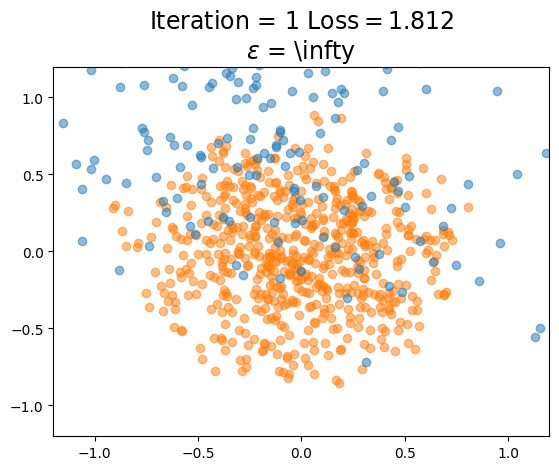

iteration =1
iteration =2 Loss: 1.0777, swd: 2.4379, bce: 0.9265
iteration =3 Loss: 0.7294, swd: 0.6368, bce: 0.7397
iteration =4 Loss: 0.6699, swd: 0.3489, bce: 0.7056
iteration =5 Loss: 0.6739, swd: 0.4527, bce: 0.6985
iteration =6 Loss: 0.6553, swd: 0.4294, bce: 0.6804
iteration =7 Loss: 0.6242, swd: 0.2696, bce: 0.6636
iteration =8 Loss: 0.6109, swd: 0.2013, bce: 0.6564
iteration =9 Loss: 0.6057, swd: 0.1265, bce: 0.6590
iteration =10 Loss: 0.5928, swd: 0.1216, bce: 0.6451
iteration =11 Loss: 0.5942, swd: 0.1367, bce: 0.6450
iteration =12 Loss: 0.5842, swd: 0.1572, bce: 0.6317
iteration =13 Loss: 0.5864, swd: 0.1682, bce: 0.6328
iteration =14 Loss: 0.5708, swd: 0.1636, bce: 0.6160
iteration =15 Loss: 0.5731, swd: 0.1446, bce: 0.6207
iteration =16 Loss: 0.5563, swd: 0.0964, bce: 0.6073
iteration =17 Loss: 0.5524, swd: 0.1168, bce: 0.6008
iteration =18 Loss: 0.5445, swd: 0.0857, bce: 0.5955
iteration =19 Loss: 0.5354, swd: 0.1018, bce: 0.5836
iteration =20 Loss: 0.5318, swd: 0.0791, 

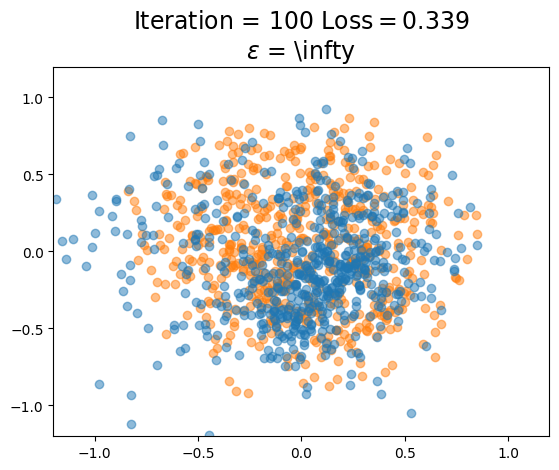

iteration =100
iteration =101 Loss: 0.3241, swd: 0.0298, bce: 0.3568
iteration =102 Loss: 0.3247, swd: 0.0276, bce: 0.3577
iteration =103 Loss: 0.3265, swd: 0.0242, bce: 0.3601
iteration =104 Loss: 0.3238, swd: 0.0221, bce: 0.3573
iteration =105 Loss: 0.3244, swd: 0.0336, bce: 0.3567
iteration =106 Loss: 0.3201, swd: 0.0312, bce: 0.3522
iteration =107 Loss: 0.3113, swd: 0.0287, bce: 0.3427
iteration =108 Loss: 0.3215, swd: 0.0266, bce: 0.3543
iteration =109 Loss: 0.3223, swd: 0.0224, bce: 0.3556
iteration =110 Loss: 0.3181, swd: 0.0323, bce: 0.3498
iteration =111 Loss: 0.3184, swd: 0.0284, bce: 0.3506
iteration =112 Loss: 0.3212, swd: 0.0300, bce: 0.3536
iteration =113 Loss: 0.3177, swd: 0.0266, bce: 0.3501
iteration =114 Loss: 0.3101, swd: 0.0250, bce: 0.3418
iteration =115 Loss: 0.3164, swd: 0.0278, bce: 0.3485
iteration =116 Loss: 0.3175, swd: 0.0224, bce: 0.3503
iteration =117 Loss: 0.3169, swd: 0.0217, bce: 0.3497
iteration =118 Loss: 0.3170, swd: 0.0275, bce: 0.3491
iteration =11

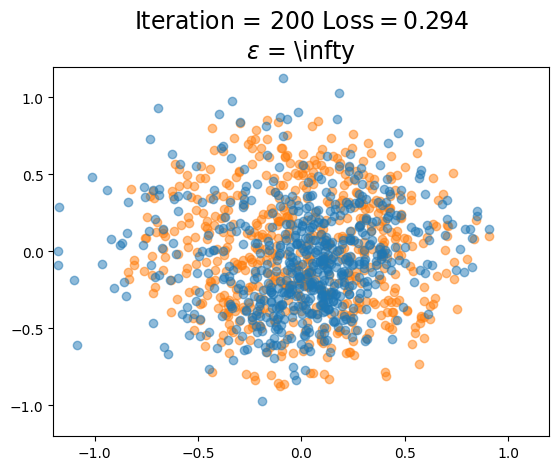

iteration =200
iteration =201 Loss: 0.2987, swd: 0.0137, bce: 0.3304
iteration =202 Loss: 0.2997, swd: 0.0154, bce: 0.3313
iteration =203 Loss: 0.2935, swd: 0.0147, bce: 0.3244
iteration =204 Loss: 0.2888, swd: 0.0169, bce: 0.3190
iteration =205 Loss: 0.3007, swd: 0.0166, bce: 0.3322
iteration =206 Loss: 0.2907, swd: 0.0131, bce: 0.3215
iteration =207 Loss: 0.2962, swd: 0.0136, bce: 0.3276
iteration =208 Loss: 0.2934, swd: 0.0177, bce: 0.3241
iteration =209 Loss: 0.2985, swd: 0.0137, bce: 0.3302
iteration =210 Loss: 0.2894, swd: 0.0152, bce: 0.3199
iteration =211 Loss: 0.2922, swd: 0.0169, bce: 0.3228
iteration =212 Loss: 0.2911, swd: 0.0158, bce: 0.3217
iteration =213 Loss: 0.2938, swd: 0.0127, bce: 0.3251
iteration =214 Loss: 0.2943, swd: 0.0158, bce: 0.3253
iteration =215 Loss: 0.2890, swd: 0.0161, bce: 0.3194
iteration =216 Loss: 0.2984, swd: 0.0128, bce: 0.3301
iteration =217 Loss: 0.2961, swd: 0.0109, bce: 0.3278
iteration =218 Loss: 0.2969, swd: 0.0141, bce: 0.3283
iteration =21

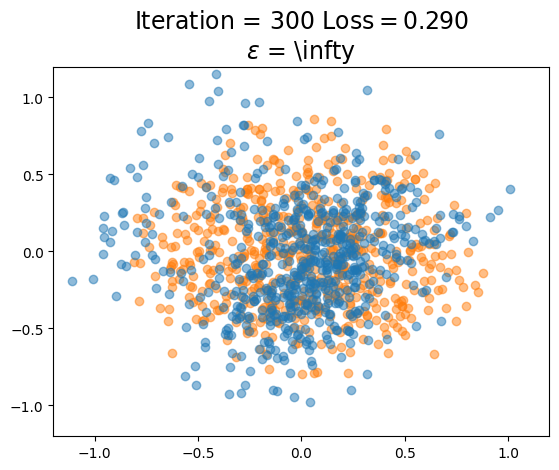

iteration =300
iteration =301 Loss: 0.2818, swd: 0.0128, bce: 0.3117
iteration =302 Loss: 0.2892, swd: 0.0085, bce: 0.3204
iteration =303 Loss: 0.2905, swd: 0.0102, bce: 0.3216
iteration =304 Loss: 0.2870, swd: 0.0111, bce: 0.3177
iteration =305 Loss: 0.2804, swd: 0.0119, bce: 0.3102
iteration =306 Loss: 0.2847, swd: 0.0119, bce: 0.3150
iteration =307 Loss: 0.2886, swd: 0.0135, bce: 0.3192
iteration =308 Loss: 0.2855, swd: 0.0115, bce: 0.3159
iteration =309 Loss: 0.2838, swd: 0.0102, bce: 0.3142
iteration =310 Loss: 0.2879, swd: 0.0096, bce: 0.3189
iteration =311 Loss: 0.2813, swd: 0.0078, bce: 0.3117
iteration =312 Loss: 0.2854, swd: 0.0102, bce: 0.3160
iteration =313 Loss: 0.2845, swd: 0.0105, bce: 0.3149
iteration =314 Loss: 0.2856, swd: 0.0100, bce: 0.3162
iteration =315 Loss: 0.2798, swd: 0.0098, bce: 0.3098
iteration =316 Loss: 0.2831, swd: 0.0091, bce: 0.3135
iteration =317 Loss: 0.2811, swd: 0.0110, bce: 0.3111
iteration =318 Loss: 0.2888, swd: 0.0110, bce: 0.3197
iteration =31

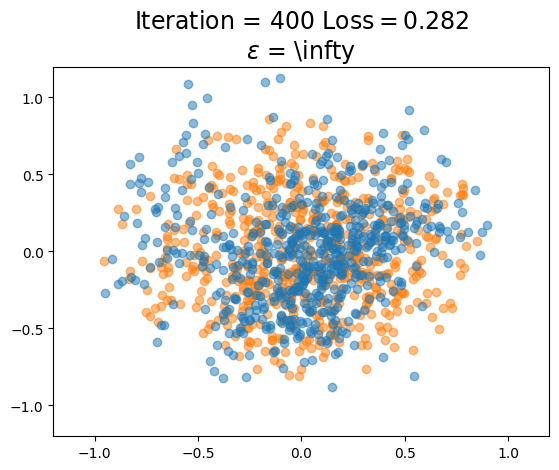

iteration =400
iteration =401 Loss: 0.2778, swd: 0.0095, bce: 0.3076
iteration =402 Loss: 0.2763, swd: 0.0096, bce: 0.3059
iteration =403 Loss: 0.2789, swd: 0.0071, bce: 0.3091
iteration =404 Loss: 0.2855, swd: 0.0090, bce: 0.3163
iteration =405 Loss: 0.2803, swd: 0.0088, bce: 0.3104
iteration =406 Loss: 0.2795, swd: 0.0083, bce: 0.3097
iteration =407 Loss: 0.2809, swd: 0.0080, bce: 0.3112
iteration =408 Loss: 0.2887, swd: 0.0100, bce: 0.3196
iteration =409 Loss: 0.2809, swd: 0.0085, bce: 0.3112
iteration =410 Loss: 0.2784, swd: 0.0098, bce: 0.3082
iteration =411 Loss: 0.2870, swd: 0.0081, bce: 0.3180
iteration =412 Loss: 0.2875, swd: 0.0089, bce: 0.3185
iteration =413 Loss: 0.2870, swd: 0.0096, bce: 0.3178
iteration =414 Loss: 0.2870, swd: 0.0099, bce: 0.3178
iteration =415 Loss: 0.2849, swd: 0.0085, bce: 0.3156
iteration =416 Loss: 0.2839, swd: 0.0098, bce: 0.3144
iteration =417 Loss: 0.2814, swd: 0.0072, bce: 0.3118
iteration =418 Loss: 0.2767, swd: 0.0095, bce: 0.3064
iteration =41

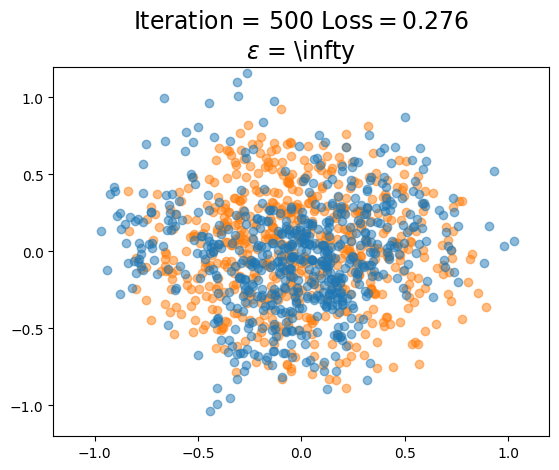

iteration =500
iteration =501 Loss: 0.2768, swd: 0.0094, bce: 0.3065
iteration =502 Loss: 0.2801, swd: 0.0077, bce: 0.3103
iteration =503 Loss: 0.2814, swd: 0.0086, bce: 0.3117
iteration =504 Loss: 0.2812, swd: 0.0087, bce: 0.3115
iteration =505 Loss: 0.2850, swd: 0.0088, bce: 0.3157
iteration =506 Loss: 0.2817, swd: 0.0087, bce: 0.3121
iteration =507 Loss: 0.2887, swd: 0.0090, bce: 0.3198
iteration =508 Loss: 0.2768, swd: 0.0079, bce: 0.3067
iteration =509 Loss: 0.2761, swd: 0.0088, bce: 0.3058
iteration =510 Loss: 0.2802, swd: 0.0085, bce: 0.3104
iteration =511 Loss: 0.2811, swd: 0.0069, bce: 0.3116
iteration =512 Loss: 0.2840, swd: 0.0082, bce: 0.3147
iteration =513 Loss: 0.2805, swd: 0.0086, bce: 0.3107
iteration =514 Loss: 0.2794, swd: 0.0078, bce: 0.3096
iteration =515 Loss: 0.2883, swd: 0.0086, bce: 0.3194
iteration =516 Loss: 0.2838, swd: 0.0093, bce: 0.3143
iteration =517 Loss: 0.2723, swd: 0.0085, bce: 0.3016
iteration =518 Loss: 0.2793, swd: 0.0078, bce: 0.3095
iteration =51

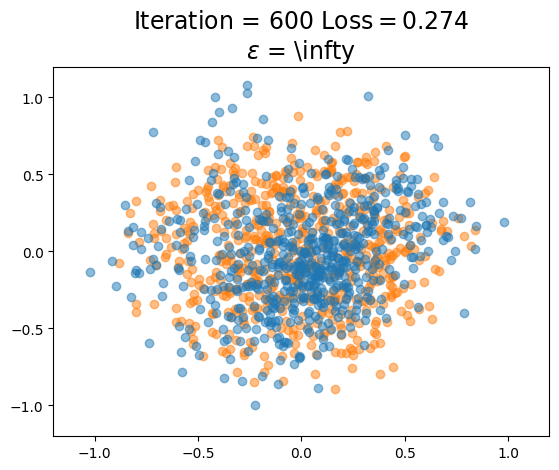

iteration =600
iteration =601 Loss: 0.2775, swd: 0.0082, bce: 0.3074
iteration =602 Loss: 0.2782, swd: 0.0067, bce: 0.3084
iteration =603 Loss: 0.2785, swd: 0.0087, bce: 0.3085
iteration =604 Loss: 0.2750, swd: 0.0072, bce: 0.3047
iteration =605 Loss: 0.2719, swd: 0.0069, bce: 0.3013
iteration =606 Loss: 0.2813, swd: 0.0065, bce: 0.3118
iteration =607 Loss: 0.2784, swd: 0.0080, bce: 0.3084
iteration =608 Loss: 0.2776, swd: 0.0070, bce: 0.3076
iteration =609 Loss: 0.2682, swd: 0.0090, bce: 0.2970
iteration =610 Loss: 0.2845, swd: 0.0075, bce: 0.3153
iteration =611 Loss: 0.2739, swd: 0.0076, bce: 0.3035
iteration =612 Loss: 0.2758, swd: 0.0070, bce: 0.3057
iteration =613 Loss: 0.2773, swd: 0.0062, bce: 0.3074
iteration =614 Loss: 0.2757, swd: 0.0079, bce: 0.3055
iteration =615 Loss: 0.2794, swd: 0.0059, bce: 0.3098
iteration =616 Loss: 0.2711, swd: 0.0081, bce: 0.3003
iteration =617 Loss: 0.2775, swd: 0.0056, bce: 0.3077
iteration =618 Loss: 0.2817, swd: 0.0063, bce: 0.3123
iteration =61

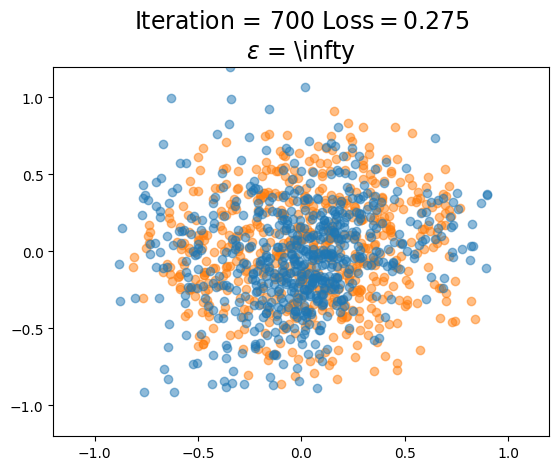

iteration =700
iteration =701 Loss: 0.2709, swd: 0.0064, bce: 0.3002
iteration =702 Loss: 0.2714, swd: 0.0068, bce: 0.3008
iteration =703 Loss: 0.2793, swd: 0.0055, bce: 0.3097
iteration =704 Loss: 0.2682, swd: 0.0059, bce: 0.2974
iteration =705 Loss: 0.2824, swd: 0.0064, bce: 0.3131
iteration =706 Loss: 0.2690, swd: 0.0056, bce: 0.2982
iteration =707 Loss: 0.2782, swd: 0.0065, bce: 0.3084
iteration =708 Loss: 0.2736, swd: 0.0076, bce: 0.3032
iteration =709 Loss: 0.2688, swd: 0.0066, bce: 0.2979
iteration =710 Loss: 0.2712, swd: 0.0053, bce: 0.3008
iteration =711 Loss: 0.2729, swd: 0.0063, bce: 0.3026
iteration =712 Loss: 0.2756, swd: 0.0067, bce: 0.3055
iteration =713 Loss: 0.2723, swd: 0.0070, bce: 0.3018
iteration =714 Loss: 0.2827, swd: 0.0061, bce: 0.3134
iteration =715 Loss: 0.2756, swd: 0.0058, bce: 0.3055
iteration =716 Loss: 0.2756, swd: 0.0046, bce: 0.3057
iteration =717 Loss: 0.2762, swd: 0.0052, bce: 0.3064
iteration =718 Loss: 0.2787, swd: 0.0075, bce: 0.3088
iteration =71

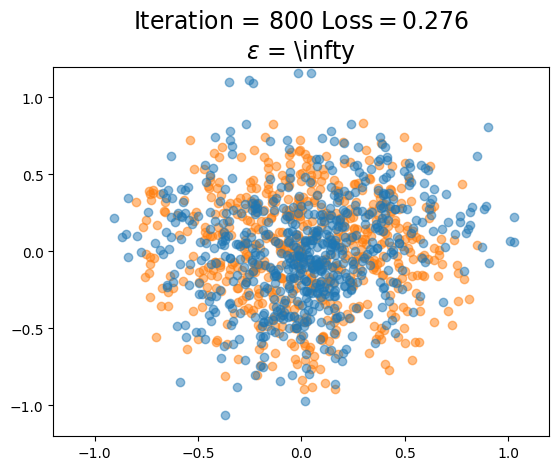

iteration =800
iteration =801 Loss: 0.2781, swd: 0.0050, bce: 0.3084
iteration =802 Loss: 0.2709, swd: 0.0052, bce: 0.3004
iteration =803 Loss: 0.2732, swd: 0.0062, bce: 0.3029
iteration =804 Loss: 0.2717, swd: 0.0056, bce: 0.3013
iteration =805 Loss: 0.2771, swd: 0.0072, bce: 0.3071
iteration =806 Loss: 0.2714, swd: 0.0048, bce: 0.3010
iteration =807 Loss: 0.2712, swd: 0.0058, bce: 0.3007
iteration =808 Loss: 0.2775, swd: 0.0057, bce: 0.3077
iteration =809 Loss: 0.2761, swd: 0.0065, bce: 0.3060
iteration =810 Loss: 0.2726, swd: 0.0057, bce: 0.3022
iteration =811 Loss: 0.2720, swd: 0.0050, bce: 0.3016
iteration =812 Loss: 0.2812, swd: 0.0054, bce: 0.3119
iteration =813 Loss: 0.2735, swd: 0.0050, bce: 0.3033
iteration =814 Loss: 0.2665, swd: 0.0053, bce: 0.2955
iteration =815 Loss: 0.2747, swd: 0.0058, bce: 0.3046
iteration =816 Loss: 0.2760, swd: 0.0057, bce: 0.3061
iteration =817 Loss: 0.2754, swd: 0.0093, bce: 0.3050
iteration =818 Loss: 0.2766, swd: 0.0055, bce: 0.3068
iteration =81

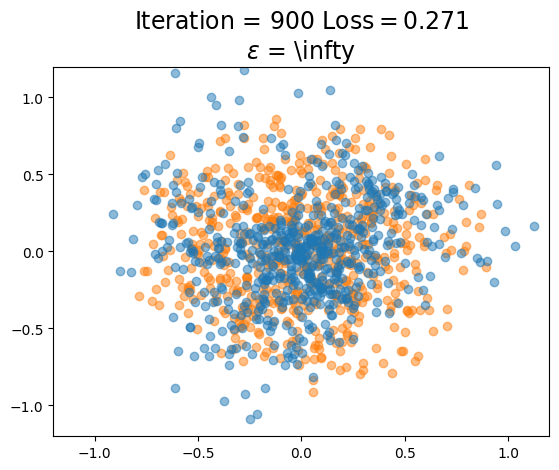

iteration =900
iteration =901 Loss: 0.2706, swd: 0.0053, bce: 0.3001
iteration =902 Loss: 0.2720, swd: 0.0044, bce: 0.3017
iteration =903 Loss: 0.2692, swd: 0.0066, bce: 0.2984
iteration =904 Loss: 0.2704, swd: 0.0042, bce: 0.2999
iteration =905 Loss: 0.2737, swd: 0.0053, bce: 0.3036
iteration =906 Loss: 0.2687, swd: 0.0054, bce: 0.2980
iteration =907 Loss: 0.2748, swd: 0.0050, bce: 0.3048
iteration =908 Loss: 0.2724, swd: 0.0052, bce: 0.3021
iteration =909 Loss: 0.2714, swd: 0.0055, bce: 0.3009
iteration =910 Loss: 0.2709, swd: 0.0057, bce: 0.3004
iteration =911 Loss: 0.2753, swd: 0.0056, bce: 0.3053
iteration =912 Loss: 0.2691, swd: 0.0060, bce: 0.2983
iteration =913 Loss: 0.2696, swd: 0.0052, bce: 0.2990
iteration =914 Loss: 0.2762, swd: 0.0054, bce: 0.3063
iteration =915 Loss: 0.2756, swd: 0.0057, bce: 0.3056
iteration =916 Loss: 0.2726, swd: 0.0052, bce: 0.3023
iteration =917 Loss: 0.2757, swd: 0.0047, bce: 0.3058
iteration =918 Loss: 0.2728, swd: 0.0060, bce: 0.3025
iteration =91

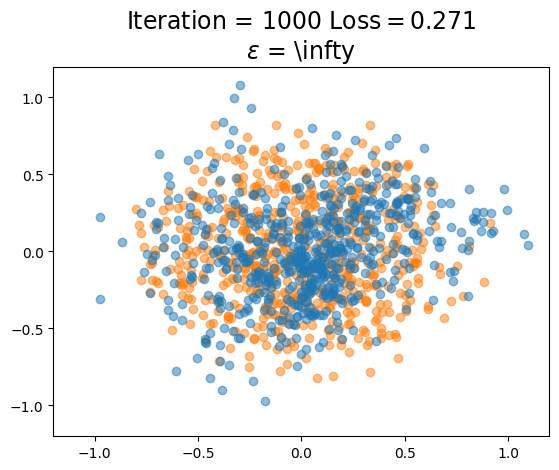

iteration =1000
iteration =1001 Loss: 0.2711, swd: 0.0052, bce: 0.3006
iteration =1002 Loss: 0.2727, swd: 0.0054, bce: 0.3024
iteration =1003 Loss: 0.2707, swd: 0.0050, bce: 0.3002
iteration =1004 Loss: 0.2697, swd: 0.0045, bce: 0.2992
iteration =1005 Loss: 0.2750, swd: 0.0055, bce: 0.3049
iteration =1006 Loss: 0.2635, swd: 0.0054, bce: 0.2921
iteration =1007 Loss: 0.2738, swd: 0.0051, bce: 0.3037
iteration =1008 Loss: 0.2695, swd: 0.0045, bce: 0.2989
iteration =1009 Loss: 0.2730, swd: 0.0055, bce: 0.3027
iteration =1010 Loss: 0.2653, swd: 0.0052, bce: 0.2942
iteration =1011 Loss: 0.2660, swd: 0.0046, bce: 0.2950
iteration =1012 Loss: 0.2690, swd: 0.0049, bce: 0.2984
iteration =1013 Loss: 0.2640, swd: 0.0055, bce: 0.2927
iteration =1014 Loss: 0.2734, swd: 0.0045, bce: 0.3033
iteration =1015 Loss: 0.2721, swd: 0.0054, bce: 0.3018
iteration =1016 Loss: 0.2777, swd: 0.0053, bce: 0.3080
iteration =1017 Loss: 0.2699, swd: 0.0047, bce: 0.2994
iteration =1018 Loss: 0.2694, swd: 0.0047, bce: 0

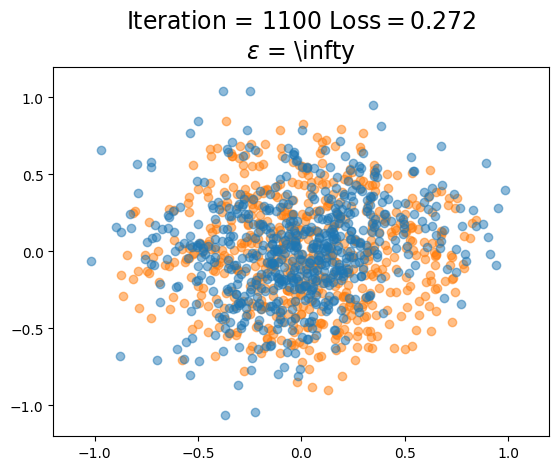

iteration =1100
iteration =1101 Loss: 0.2634, swd: 0.0052, bce: 0.2921
iteration =1102 Loss: 0.2720, swd: 0.0040, bce: 0.3018
iteration =1103 Loss: 0.2691, swd: 0.0050, bce: 0.2985
iteration =1104 Loss: 0.2720, swd: 0.0042, bce: 0.3017
iteration =1105 Loss: 0.2704, swd: 0.0055, bce: 0.2999
iteration =1106 Loss: 0.2747, swd: 0.0057, bce: 0.3046
iteration =1107 Loss: 0.2785, swd: 0.0054, bce: 0.3088
iteration =1108 Loss: 0.2697, swd: 0.0043, bce: 0.2992
iteration =1109 Loss: 0.2708, swd: 0.0050, bce: 0.3004
iteration =1110 Loss: 0.2719, swd: 0.0050, bce: 0.3016
iteration =1111 Loss: 0.2707, swd: 0.0046, bce: 0.3002
iteration =1112 Loss: 0.2687, swd: 0.0043, bce: 0.2980
iteration =1113 Loss: 0.2686, swd: 0.0047, bce: 0.2979
iteration =1114 Loss: 0.2632, swd: 0.0053, bce: 0.2919
iteration =1115 Loss: 0.2713, swd: 0.0041, bce: 0.3010
iteration =1116 Loss: 0.2692, swd: 0.0049, bce: 0.2986
iteration =1117 Loss: 0.2711, swd: 0.0048, bce: 0.3007
iteration =1118 Loss: 0.2730, swd: 0.0052, bce: 0

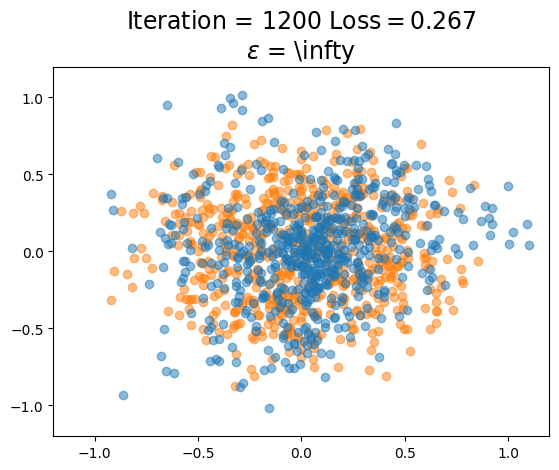

iteration =1200
iteration =1201 Loss: 0.2651, swd: 0.0047, bce: 0.2940
iteration =1202 Loss: 0.2665, swd: 0.0043, bce: 0.2957
iteration =1203 Loss: 0.2701, swd: 0.0048, bce: 0.2996
iteration =1204 Loss: 0.2727, swd: 0.0038, bce: 0.3026
iteration =1205 Loss: 0.2682, swd: 0.0051, bce: 0.2975
iteration =1206 Loss: 0.2690, swd: 0.0043, bce: 0.2984
iteration =1207 Loss: 0.2664, swd: 0.0040, bce: 0.2955
iteration =1208 Loss: 0.2675, swd: 0.0045, bce: 0.2967
iteration =1209 Loss: 0.2672, swd: 0.0044, bce: 0.2964
iteration =1210 Loss: 0.2693, swd: 0.0049, bce: 0.2987
iteration =1211 Loss: 0.2677, swd: 0.0048, bce: 0.2969
iteration =1212 Loss: 0.2680, swd: 0.0047, bce: 0.2973
iteration =1213 Loss: 0.2700, swd: 0.0045, bce: 0.2995
iteration =1214 Loss: 0.2719, swd: 0.0053, bce: 0.3015
iteration =1215 Loss: 0.2660, swd: 0.0040, bce: 0.2951
iteration =1216 Loss: 0.2641, swd: 0.0045, bce: 0.2929
iteration =1217 Loss: 0.2671, swd: 0.0049, bce: 0.2962
iteration =1218 Loss: 0.2730, swd: 0.0044, bce: 0

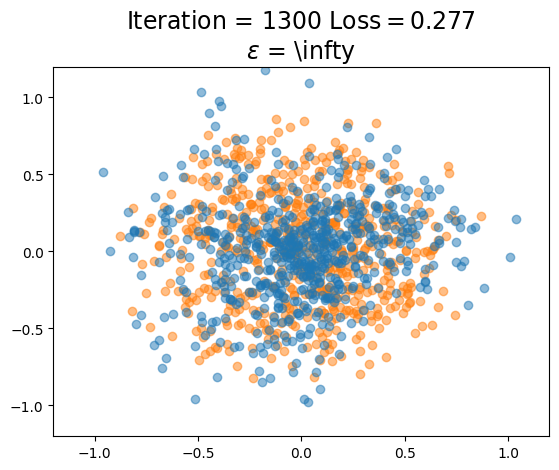

iteration =1300
iteration =1301 Loss: 0.2657, swd: 0.0040, bce: 0.2948
iteration =1302 Loss: 0.2682, swd: 0.0048, bce: 0.2975
iteration =1303 Loss: 0.2664, swd: 0.0040, bce: 0.2956
iteration =1304 Loss: 0.2653, swd: 0.0052, bce: 0.2942
iteration =1305 Loss: 0.2705, swd: 0.0040, bce: 0.3001
iteration =1306 Loss: 0.2755, swd: 0.0044, bce: 0.3056
iteration =1307 Loss: 0.2685, swd: 0.0041, bce: 0.2979
iteration =1308 Loss: 0.2606, swd: 0.0053, bce: 0.2890
iteration =1309 Loss: 0.2701, swd: 0.0048, bce: 0.2996
iteration =1310 Loss: 0.2679, swd: 0.0043, bce: 0.2972
iteration =1311 Loss: 0.2694, swd: 0.0048, bce: 0.2988
iteration =1312 Loss: 0.2703, swd: 0.0053, bce: 0.2998
iteration =1313 Loss: 0.2731, swd: 0.0055, bce: 0.3029
iteration =1314 Loss: 0.2729, swd: 0.0037, bce: 0.3028
iteration =1315 Loss: 0.2733, swd: 0.0048, bce: 0.3032
iteration =1316 Loss: 0.2721, swd: 0.0044, bce: 0.3019
iteration =1317 Loss: 0.2660, swd: 0.0039, bce: 0.2951
iteration =1318 Loss: 0.2715, swd: 0.0046, bce: 0

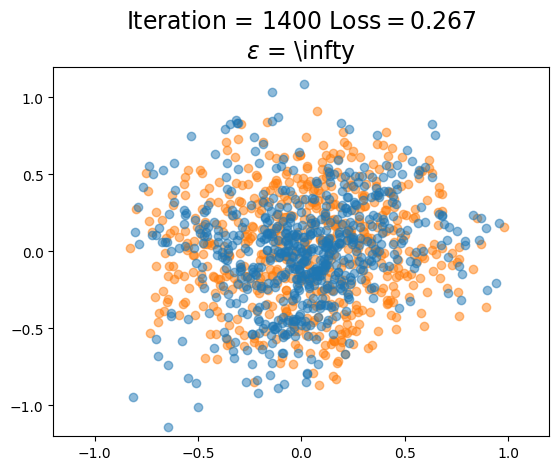

iteration =1400
iteration =1401 Loss: 0.2642, swd: 0.0040, bce: 0.2931
iteration =1402 Loss: 0.2707, swd: 0.0039, bce: 0.3004
iteration =1403 Loss: 0.2685, swd: 0.0051, bce: 0.2978
iteration =1404 Loss: 0.2741, swd: 0.0046, bce: 0.3041
iteration =1405 Loss: 0.2671, swd: 0.0037, bce: 0.2963
iteration =1406 Loss: 0.2679, swd: 0.0041, bce: 0.2973
iteration =1407 Loss: 0.2687, swd: 0.0042, bce: 0.2981
iteration =1408 Loss: 0.2673, swd: 0.0044, bce: 0.2966
iteration =1409 Loss: 0.2706, swd: 0.0045, bce: 0.3002
iteration =1410 Loss: 0.2666, swd: 0.0038, bce: 0.2958
iteration =1411 Loss: 0.2668, swd: 0.0045, bce: 0.2959
iteration =1412 Loss: 0.2677, swd: 0.0034, bce: 0.2971
iteration =1413 Loss: 0.2677, swd: 0.0040, bce: 0.2970
iteration =1414 Loss: 0.2714, swd: 0.0046, bce: 0.3011
iteration =1415 Loss: 0.2738, swd: 0.0040, bce: 0.3038
iteration =1416 Loss: 0.2659, swd: 0.0040, bce: 0.2950
iteration =1417 Loss: 0.2633, swd: 0.0034, bce: 0.2921
iteration =1418 Loss: 0.2755, swd: 0.0037, bce: 0

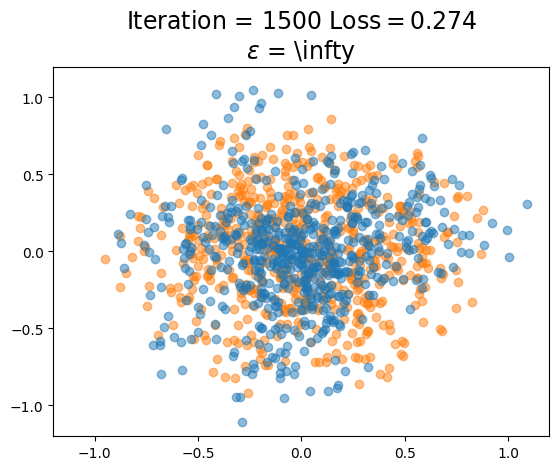

iteration =1500
iteration =1501 Loss: 0.2681, swd: 0.0051, bce: 0.2974
iteration =1502 Loss: 0.2753, swd: 0.0044, bce: 0.3054
iteration =1503 Loss: 0.2679, swd: 0.0039, bce: 0.2972
iteration =1504 Loss: 0.2721, swd: 0.0041, bce: 0.3019
iteration =1505 Loss: 0.2579, swd: 0.0045, bce: 0.2860
iteration =1506 Loss: 0.2680, swd: 0.0039, bce: 0.2973
iteration =1507 Loss: 0.2647, swd: 0.0036, bce: 0.2938
iteration =1508 Loss: 0.2702, swd: 0.0038, bce: 0.2998
iteration =1509 Loss: 0.2664, swd: 0.0043, bce: 0.2955
iteration =1510 Loss: 0.2675, swd: 0.0045, bce: 0.2968
iteration =1511 Loss: 0.2712, swd: 0.0038, bce: 0.3009
iteration =1512 Loss: 0.2665, swd: 0.0038, bce: 0.2957
iteration =1513 Loss: 0.2670, swd: 0.0036, bce: 0.2963
iteration =1514 Loss: 0.2635, swd: 0.0038, bce: 0.2924
iteration =1515 Loss: 0.2716, swd: 0.0049, bce: 0.3012
iteration =1516 Loss: 0.2636, swd: 0.0048, bce: 0.2924
iteration =1517 Loss: 0.2693, swd: 0.0037, bce: 0.2988
iteration =1518 Loss: 0.2667, swd: 0.0044, bce: 0

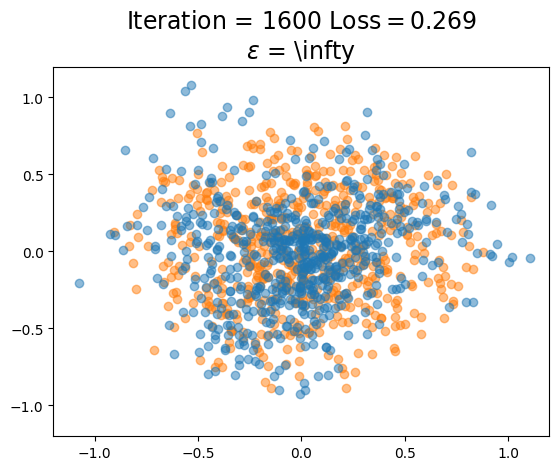

iteration =1600
iteration =1601 Loss: 0.2696, swd: 0.0047, bce: 0.2990
iteration =1602 Loss: 0.2698, swd: 0.0036, bce: 0.2993
iteration =1603 Loss: 0.2628, swd: 0.0041, bce: 0.2916
iteration =1604 Loss: 0.2690, swd: 0.0044, bce: 0.2984
iteration =1605 Loss: 0.2681, swd: 0.0041, bce: 0.2974
iteration =1606 Loss: 0.2631, swd: 0.0042, bce: 0.2918
iteration =1607 Loss: 0.2696, swd: 0.0033, bce: 0.2992
iteration =1608 Loss: 0.2623, swd: 0.0045, bce: 0.2909
iteration =1609 Loss: 0.2723, swd: 0.0046, bce: 0.3020
iteration =1610 Loss: 0.2674, swd: 0.0039, bce: 0.2966
iteration =1611 Loss: 0.2674, swd: 0.0040, bce: 0.2967
iteration =1612 Loss: 0.2645, swd: 0.0046, bce: 0.2934
iteration =1613 Loss: 0.2713, swd: 0.0043, bce: 0.3010
iteration =1614 Loss: 0.2636, swd: 0.0042, bce: 0.2925
iteration =1615 Loss: 0.2689, swd: 0.0047, bce: 0.2983
iteration =1616 Loss: 0.2676, swd: 0.0037, bce: 0.2969
iteration =1617 Loss: 0.2650, swd: 0.0038, bce: 0.2940
iteration =1618 Loss: 0.2689, swd: 0.0042, bce: 0

In [ ]:
for alpha in alpha_values:
    print(f'alpha ={alpha}')
    losses_array = jnp.zeros((2,num_iterations))
    counter = -1
    
    for epsilon in epsilon_values: 
        counter = counter+1
        print(f'epsilon ={epsilon}')
    
        # compute the noise needed for a given epsilon
        if epsilon == '\infty':
            M = 10**7
            L = 10**7
            C = 10**7 
            noise = 0
            
        else: 
            M = M0
            L = L0
            C = C0 
            sensitivity = (1-alpha)*2*C/(m0) + alpha*12*M*jnp.sqrt(d)*L/m0
            sampling_rate = m0/n0
            actual_noise = find_noise_for_epsilon(num_iterations, delta, sampling_rate, epsilon, tolerance=1e-4)
            noise = actual_noise*sensitivity
    
                    
        # Initialize model
        key_model = random.PRNGKey(42)  # same initialization for every epsilon 
        model = conv_mnist(key_model, d)  
        params0 = model.params
        flat_params, unflatten_params = ravel_pytree(params0)
    
        # init optimizer state
        opt_state = optimizer.init(flat_params)
    
        # Training loop
        accountantX = create_accountant("gdp")
        losses = []
        flat_params, unflatten_params = ravel_pytree(params0)
        # key = jax.random.PRNGKey(0)
                          
        # Start the loop
        for iteration in range(num_iterations):
            print(f'iteration ={iteration}')
                
           # select randomly a batch
            key, subkey = split(key,2)
            index = jax.random.choice(subkey, X0.shape[0], shape=(m0,), replace=False)
            X0_batch  = X0[index,]
            X1_batch  = X1[index,]
    
            # Genarate k random direction for the Monte Carlo approximation of the sliced Wasserstein distance
            key, subkey = split(key)
            random_directions = normal(subkey, (num_projections, d))
            random_directions /= jnp.linalg.norm(random_directions, axis=1, keepdims=True)
                
            # Sliced wasserstein clipped gradient in the batch
            gradient_flat_params_sliced = gradient_sliced_flow(flat_params, unflatten_params, X0_batch , X1_batch, model,
                                                        R_vector_batch, indexes_batch, M, L, random_directions, minibatch_number, parallel = True) #  <- CHANGE PARALLELIZATION!!!!!!!!!!!!!
    
            # Reconstruction loss clipped gradient in the batch
            gradient_flat_params_reconstruction = gradient_reconstruction_loss(flat_params, unflatten_params, X0_batch, model, C, parallel = True) #  <- CHANGE PARALLELIZATION!!!!!!!!!!!!!

            # Gradient of the regularized loss function
            gradient_flat_params = (1-alpha)*gradient_flat_params_reconstruction + alpha*gradient_flat_params_sliced
    
        
            # Private gradient: add noise to the previous gradient 
            key, subkey = split(key)
            gradient_flat_params_noisy =  gradient_flat_params + noise*normal(subkey,gradient_flat_params.shape[0])
    
    
            # Perform the accountant step
            if epsilon != '\infty':
                accountantX.step(noise_multiplier=actual_noise, sample_rate=sampling_rate)
               
            # Perform the gradient update
            updates, opt_state = optimizer.update(gradient_flat_params_noisy, opt_state, flat_params)
            flat_params = optax.apply_updates(flat_params, updates)
    
            # Compute the value of the loss in the batch
            U_batch = model.penalized_layer(X0_batch, unflatten_params(flat_params))
            V_batch = X1_batch
            swd_loss,_,_ = sliced_wasserstein(U_batch, X1_batch, R_vector_batch, indexes_batch, random_directions, return_gradient = False)
            rec_loss = bce_loss(unflatten_params(flat_params), model, X0_batch)
            loss =  (1-alpha)*rec_loss + alpha*swd_loss
                    
            # Store the loss
            losses_array = losses_array.at[counter,iteration].set(loss)
            losses.append(loss)
            print(f"Iteration {iteration + 1}, Loss: {loss:.4f}, swd: {swd_loss:.4f}, bce: {rec_loss:.4f}", end='\r', flush=True)
                
                
            # Visualization every x iterations
            if iteration==0 or (iteration+1) % 100 == 0:
                epsilon_now_X='\infty'
                if epsilon != '\infty':
                    epsilon_now_X = accountantX.get_epsilon(delta=delta, poisson = False)
                                                   
                # Crear histogramas superpuestos
                transparency = 0.5
                plt.xlim(-1.2, 1.2)  # Set x-axis limits
                plt.ylim(-1.2, 1.2)  # Set x-axis limits
                plt.scatter(V_batch[:,0], V_batch[:,1], alpha =transparency, color = colors[1])
                plt.scatter(U_batch[:,0], U_batch[:,1], alpha=transparency, color = colors[0])
                plt.title(f'Iteration = {iteration+1} Loss$ = {loss:.3f}$\n'
                          f'$\epsilon$ = {epsilon_now_X}', fontsize=17)
                plt.show()
                
        model.params = unflatten_params(flat_params)

        # save parameters
        with open(os.path.join(output_dir, f"model_eps_{epsilon_values[counter]}_alpha_{alpha}.pkl"), "wb") as f:
            pickle.dump(model.params, f)
        
        # Plot of the loss curve for different values of epsilon
        for i in range(counter+1):
            plt.plot(losses_array[i,:], label = f' $\\epsilon = {epsilon_values[i]}$')
        plt.legend()
        plt.xlabel("Iterations")
        plt.title(f' Loss curve,')
        filename = f"losses_alpha_{alpha}.svg"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300, format='svg', bbox_inches='tight') 
        plt.show()
    
        # OTHER INTERESTING PLOTS FOR THE COMPUTED SOLUTION 
    
        # 1) PLOT THE RECONSTRUCTION OF THE FIRST IMAGES 
       
        n_samples = 10
        index_label = get_first_indexes(label_test, n_samples)
        X_sample = x_test[index_label]
        X_reconstructed = model.forward(X_sample, model.params)
        
        # Plot original and reconstructed images
        plt.figure(figsize=(16, 3))
        plt.suptitle(f"Original vs Reconstructed - Latent Dim = {d}", fontsize=16)
        
        for i in range(n_samples):
            # Original
            plt.subplot(2, n_samples, i + 1)
            plt.imshow(X_sample[i, 0, :, :], cmap="gray")
            plt.axis("off")
            # Reconstructed
            plt.subplot(2, n_samples, n_samples + i + 1)
            plt.imshow(X_reconstructed[i, 0, :, :], cmap="gray")
            plt.axis("off")
        plt.savefig(os.path.join(output_dir, f"reconstruction_eps_{epsilon_values[counter]}_alpha_{alpha}.jpg"), dpi=300)
        plt.show()
    
        # 2) PLOT OF THE EMBEDDING SPACE COLORED BY LABELS
    
        Z = model.encode(X0, model.params)  # (batch_size, 2)
        
        if d == 2:   
            plt.figure(figsize=(6, 5))
            scatter = plt.scatter(Z[:, 0], Z[:, 1], c=label, cmap='tab10', alpha=0.6)
            plt.colorbar(scatter, label="Label Class")
            plt.title("Encoded Latent Space (Z)")
            plt.xlabel("Latent Dimension 1")
            plt.ylabel("Latent Dimension 2")
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f"latent_space_{epsilon_values[counter]}alpha_{alpha}.svg"))
            plt.show()
        else:
            Z_np = np.array(Z)
            label_np = np.array(label)
        
            df = pd.DataFrame(Z_np, columns=[f"z{i}" for i in range(Z_np.shape[1])])
            df['label'] = label_np
        
            g = sns.pairplot(df, hue='label', palette='tab10', corner=True, plot_kws={'alpha': 0.1, 's': 10})
            g.fig.set_size_inches(10, 10)
        
            # Set the same limits for all the subplots
            for ax in g.axes.flat:
                if ax is not None:
                    ax.set_xlim(-1.6, 1.6)
                    ax.set_ylim(-1.6, 1.6)
        
            plt.suptitle("Latent Space Pairwise Plot", y=1.02)
            g.fig.savefig(os.path.join(output_dir, f"latent_space_eps_{epsilon_values[counter]}alpha_{alpha}.jpg"), dpi=300)
            plt.show()

        # PRIVATE DATA GENERATION
        n_samples = 10
        key, subkey = random.split(key, 2)
        random_encodings = sample_unit_ball(subkey, 2*n_samples, dim= d)
        private_data = model.decode(random_encodings, model.params)
        
        # Plot original and reconstructed images
        plt.figure(figsize=(16, 3))
        plt.suptitle(f"Private generated data, d = {d}", fontsize=16)
        
        for i in range(n_samples):
            # Generated private data
            plt.subplot(2, n_samples, i + 1)
            plt.imshow(private_data[i, 0, :, :], cmap="gray")
            plt.axis("off")
            # Generated private data
            plt.subplot(2, n_samples, n_samples +  i + 1)
            plt.imshow(private_data[n_samples + i, 0, :, :], cmap="gray")
            plt.axis("off")
        plt.savefig(os.path.join(output_dir, f"generated_{epsilon_values[counter]}_alpha_{alpha}.jpg"), dpi=300)
        plt.show()

In [ ]:
end_time = time.time()
total_seconds = end_time - start_time
total_hours = total_seconds / 3600
print(f"Total runtime: {total_hours:.2f} hours")

In [ ]:
index_label = get_first_indexes(label_test, n_samples)
X_sample = x_test[index_label]
counter = -1

for epsilon in epsilon_values: 

    counter = counter + 1

    file_path = os.path.join(output_dir, f"model_eps_{epsilon_values[counter]}_alpha_{alpha}.pkl")
    with open(file_path, "rb") as f:
        params = pickle.load(f)
    
    print(f"Parámetros cargados correctamente desde {file_path}")
    n_samples = 10
    

    X_latent = model.encode(X_sample, params)
    
    def linear_interpolation(z1, z2, n_steps=10):
        """
        Returns n_steps linear interpolations between z1 and z2
        """
        alphas = jnp.linspace(0, 1, n_steps)
        return jnp.array([(1 - a) * z1 + a * z2 for a in alphas])
    
    n_steps = 10
    interpolations = []
    
    for i in range(n_samples):
        for j in range(i + 1, n_samples):  # all unique pairs
            z_interp = linear_interpolation(X_latent[i], X_latent[j], n_steps)
            X_recon = jnp.array([model.decode(z, params) for z in z_interp])
            X_recon_new = X_recon.reshape(10, 1, 28, 28)
            interpolations.append(X_recon_new)  # store pair indices and reconstructed images
    
    # len(interpolations)=45
    
    num_pairs = len(interpolations)   # should be 45
    fig, axes = plt.subplots(num_pairs, n_steps, figsize=(n_steps, num_pairs))
    
    for row in range(num_pairs):
        X_iter = interpolations[row]   # shape: (n_steps, 1, 28, 28)
    
        for col in range(n_steps):
            ax = axes[row, col]
            ax.imshow(X_iter[col, 0, :, :], cmap="gray")
            ax.axis("off")
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir,f"interpolations_eps_{epsilon_values[counter]}.jpg"), dpi=300)
    plt.show()

In [ ]:
# 1) PLOT THE RECONSTRUCTION OF THE FIRST IMAGES 
       
n_samples = 10
index_label = get_first_indexes(label_test, n_samples)
X_sample = x_test[index_label]

X_latent = model.encode(X_sample, model.params)

X_reconstructed = model.forward(X_sample, model.params)
        
# Plot original and reconstructed images
plt.figure(figsize=(16, 3))
plt.suptitle(f"Original vs Reconstructed - Latent Dim = {d}", fontsize=16)
        
for i in range(n_samples):
    # Original
    plt.subplot(2, n_samples, i + 1)
    plt.imshow(X_sample[i, 0, :, :], cmap="gray")
    plt.axis("off")
    # Reconstructed
    plt.subplot(2, n_samples, n_samples + i + 1)
    plt.imshow(X_reconstructed[i, 0, :, :], cmap="gray")
    plt.axis("off")
#plt.savefig(os.path.join(output_dir, f"reconstruction_eps_{epsilon_values[counter]}_alpha_{alpha}.jpg"), dpi=300)
plt.show()
    

In [ ]:
n_samples = 10
index_label = get_first_indexes(label_test, n_samples)
X_sample = x_test[index_label]

X_latent = model.encode(X_sample, model.params)

def linear_interpolation(z1, z2, n_steps=10):
    """
    Returns n_steps linear interpolations between z1 and z2
    """
    alphas = jnp.linspace(0, 1, n_steps)
    return jnp.array([(1 - a) * z1 + a * z2 for a in alphas])

n_steps = 10
interpolations = []

for i in range(n_samples):
    for j in range(i + 1, n_samples):  # all unique pairs
        z_interp = linear_interpolation(X_latent[i], X_latent[j], n_steps)
        X_recon = jnp.array([model.decode(z, model.params) for z in z_interp])
        X_recon_new = X_recon.reshape(10, 1, 28, 28)
        interpolations.append(X_recon_new)  # store pair indices and reconstructed images

# len(interpolations)=45

num_pairs = len(interpolations)   # should be 45
fig, axes = plt.subplots(num_pairs, n_steps, figsize=(n_steps, num_pairs))

for row in range(num_pairs):
    X_iter = interpolations[row]   # shape: (n_steps, 1, 28, 28)

    for col in range(n_steps):
        ax = axes[row, col]
        ax.imshow(X_iter[col, 0, :, :], cmap="gray")
        ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "interpolations.jpg"), dpi=300)
plt.show()

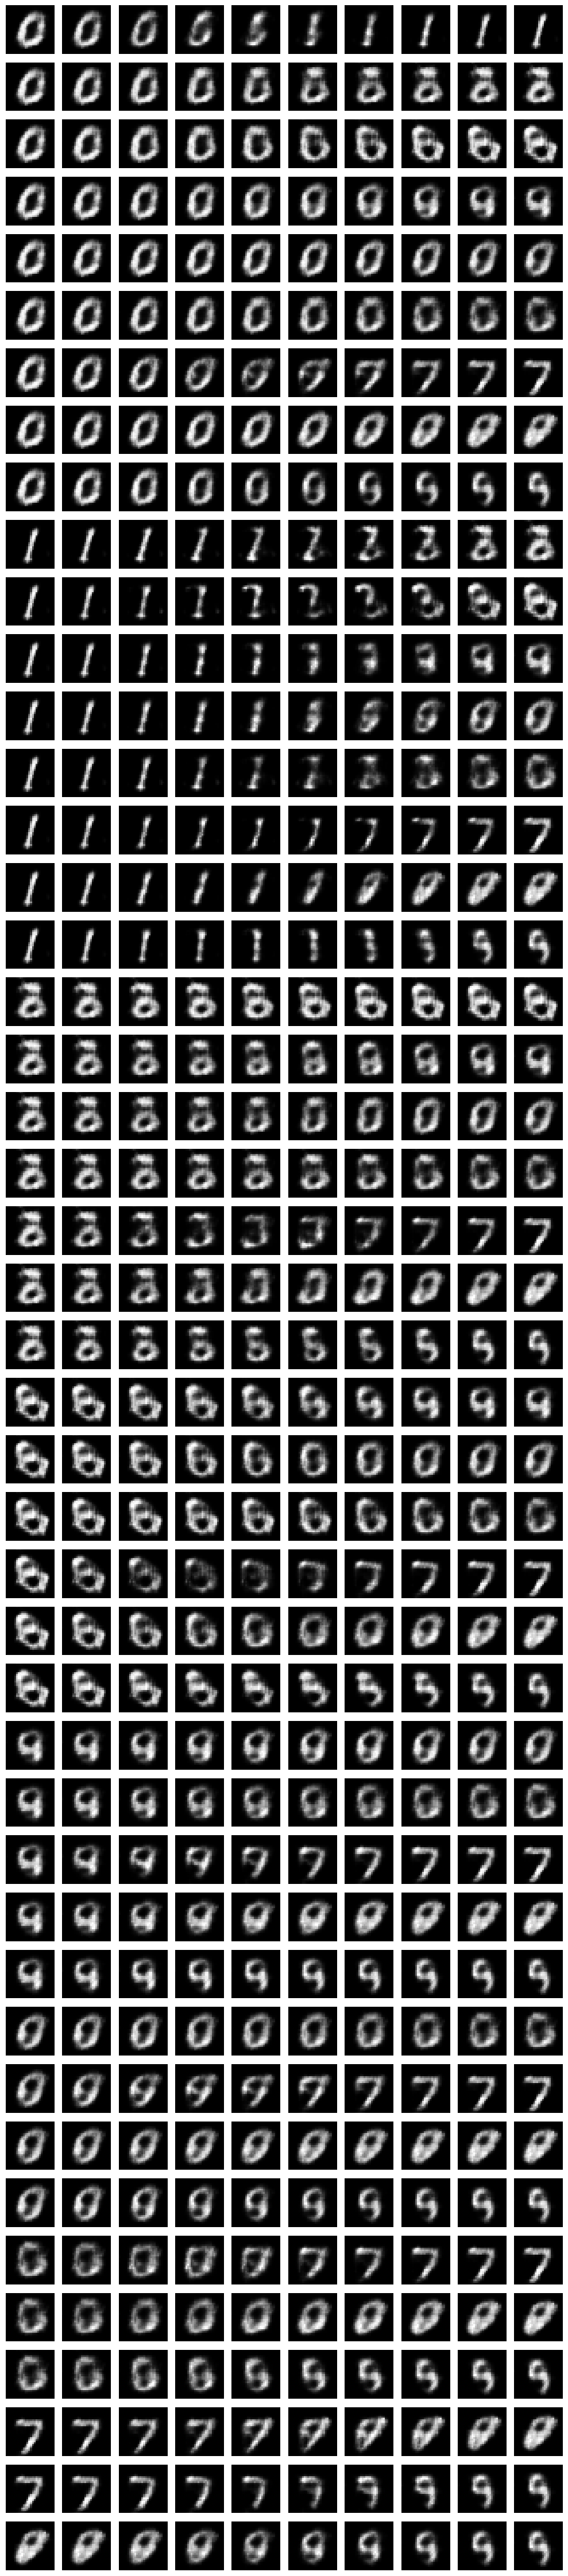